# LAB11 — Saktësia e GPS/GNSS dhe Variacioni i Pozicionit
---
- ##### Tema: **Shpërndarja statistikore e pozicionit të matur me smartphone.**
- ##### Studenti: Florian Loka
- ##### Pedagogu: Ervin Kafexhiu
- ##### Data: 26.05.2026
---


## **Qëllimi (Purpose)**

Të studiohet se si **ndryshon pozicioni i matur** nga një smartphone edhe kur telefoni
qëndron i palëvizur. Pozicioni nuk trajtohet si një numër i vetëm “i saktë”, por si një
**madhësi eksperimentale me variacion, devijim dhe pasiguri**. Krahasojmë saktësinë në
qiell të hapur me atë pranë një ndërtese.


## **Hyrje Teorike (Theory)**

**GNSS** (Global Navigation Satellite Systems) përfshin GPS, Galileo, GLONASS dhe BeiDou.
Marrësi llogarit largësinë nga të paktën **katër satelitë** (përmes kohës së mbërritjes
së sinjalit) dhe prej tyre nxjerr pozicionin dhe kohën.

Saktësia nuk është konstante: smartphone-t janë tipikisht të saktë brenda rreth
**4.9 m** në qiell të hapur, por saktësia përkeqësohet pranë ndërtesave dhe pengesave.

Për zona të vogla, ndryshimet e koordinatave kthehen në metra me një projeksion lokal:

$$ x = R\cos(\bar\phi)\,(\lambda-\bar\lambda), \qquad y = R\,(\phi-\bar\phi), \qquad
   r = \sqrt{x^2+y^2} $$

ku $R=6\,371\,000$ m, $\phi$ latitude dhe $\lambda$ longitude (në radianë). Madhësitë
karakteristike janë $\sigma_x,\sigma_y$ dhe rrezet $r_{68},r_{95}$ brenda të cilave bien
68% / 95% e matjeve.


## **Aparatura dhe Pajisjet (Apparatus)**

- Smartphone me GPS/GNSS.
- Aplikacion regjistrimi: **phyphox** (*Location GPS*) ose **GPSLogger** (eksport CSV/GPX).
- Laptop me Python/Jupyter.
- Sipërfaqe fikse për të mbajtur telefonin të palëvizur.

> **Shënim për të dhënat:** Skedarët në `data/` këtu janë **reprezentativë** (të
> simuluar rreth një pike fikse) për të demonstruar analizën. Zëvendësoji me regjistrimet
> e tua reale `gps_outdoor_stationary.csv` dhe `gps_near_building.csv`; kontrollo emrat e
> kolonave me `df.columns` dhe përshtati `lat_col/lon_col` nëse ndryshojnë.


## **Procedura (Procedure)**

1. Dil në hapësirë të hapur; vendos telefonin fiks mbi një sipërfaqe të qëndrueshme.
2. Hap aplikacionin GPS dhe prit 1–2 min që sinjali të stabilizohet.
3. Regjistro **5–10 min** me interval ~**1 s**; eksporto në CSV.
4. Përsërit matjen pranë një ndërtese (kushte më të këqija sinjali).
5. Ruaj skedarët në `data/` dhe analizoji në Python (konvertim në metra, grafikë, statistika).


## **Përpunimi Paraprak i të Dhënave (Preprocessing)**

Ngarkojmë të dy regjistrimet, heqim vlerat boshe dhe i konvertojmë koordinatat në metra
rreth pozicionit mesatar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
R = 6_371_000  # rrezja mesatare e Tokes (m)

def load_gps(fname, lat_col="latitude", lon_col="longitude"):
    df = pd.read_csv(fname).dropna(subset=[lat_col, lon_col])
    lat = np.deg2rad(df[lat_col].to_numpy()); lon = np.deg2rad(df[lon_col].to_numpy())
    lat0, lon0 = lat.mean(), lon.mean()
    x = R * np.cos(lat0) * (lon - lon0)
    y = R * (lat - lat0)
    r = np.hypot(x, y)
    return x, y, r

x_o, y_o, r_o = load_gps("data/gps_outdoor_stationary.csv")
x_b, y_b, r_b = load_gps("data/gps_near_building.csv")
print("Qiell i hapur:   ", len(r_o), "pika")
print("Pranë ndërtesës: ", len(r_b), "pika")

Qiell i hapur:    400 pika
Pranë ndërtesës:  400 pika


## **Analiza e të Dhënave (Analysis)**

Vizualizojmë shpërndarjen 2D, ndryshimin në kohë dhe histogramin e devijimit radial.

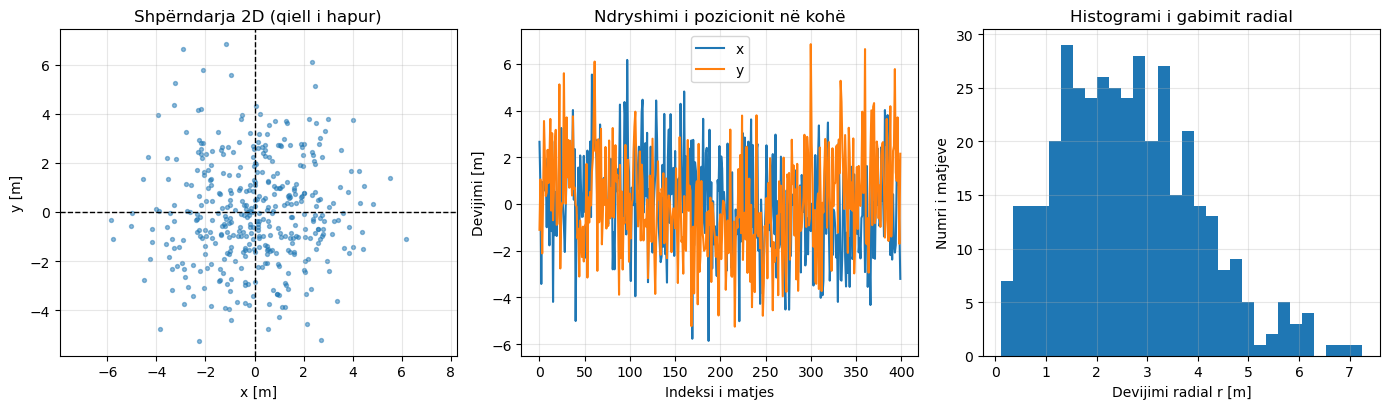

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
# 1) Shperndarja 2D (qiell i hapur)
ax[0].scatter(x_o, y_o, s=8, alpha=0.5)
ax[0].axhline(0, ls="--", lw=1, c="k"); ax[0].axvline(0, ls="--", lw=1, c="k")
ax[0].set_xlabel("x [m]"); ax[0].set_ylabel("y [m]")
ax[0].set_title("Shpërndarja 2D (qiell i hapur)"); ax[0].axis("equal"); ax[0].grid(alpha=0.3)
# 2) Pozicioni ne kohe
ax[1].plot(x_o, label="x"); ax[1].plot(y_o, label="y")
ax[1].set_xlabel("Indeksi i matjes"); ax[1].set_ylabel("Devijimi [m]")
ax[1].set_title("Ndryshimi i pozicionit në kohë"); ax[1].legend(); ax[1].grid(alpha=0.3)
# 3) Histogrami radial
ax[2].hist(r_o, bins=30)
ax[2].set_xlabel("Devijimi radial r [m]"); ax[2].set_ylabel("Numri i matjeve")
ax[2].set_title("Histogrami i gabimit radial"); ax[2].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "gps_outdoor_analiza.png", dpi=150)
plt.show()

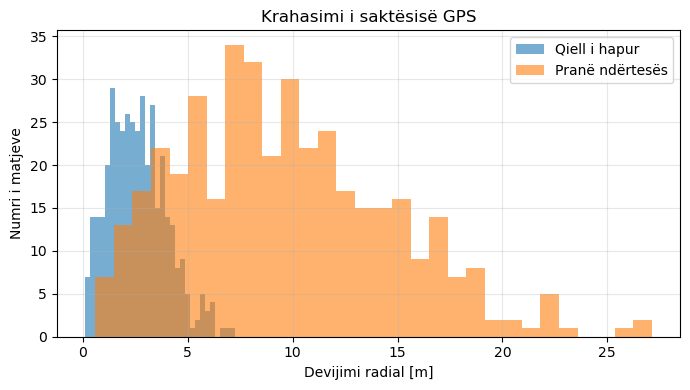

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(r_o, bins=30, alpha=0.6, label="Qiell i hapur")
ax.hist(r_b, bins=30, alpha=0.6, label="Pranë ndërtesës")
ax.set_xlabel("Devijimi radial [m]"); ax.set_ylabel("Numri i matjeve")
ax.set_title("Krahasimi i saktësisë GPS"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "gps_krahasimi.png", dpi=150)
plt.show()

## **Analiza e Pasigurisë (Uncertainty)**

Saktësia karakterizohet nga $\sigma_x,\sigma_y$ dhe nga rrezet $r_{68}$ (≈ $1\sigma$
radial) dhe $r_{95}$ (≈ $2\sigma$). $r_{95}$ është rrezja brenda së cilës bien 95% e
matjeve — një masë e zakonshme e saktësisë së pozicionit.

In [4]:
def perms(x, y, r):
    return dict(N=len(r), sx=np.std(x,ddof=1), sy=np.std(y,ddof=1),
                r68=np.percentile(r,68), r95=np.percentile(r,95), rmax=r.max())

tab = {"Qiell i hapur": perms(x_o,y_o,r_o), "Pranë ndërtesës": perms(x_b,y_b,r_b)}
print(f"{'Kushti':<16}{'N':>5}{'σx[m]':>8}{'σy[m]':>8}{'r68[m]':>8}{'r95[m]':>8}{'rmax[m]':>9}")
for k,v in tab.items():
    print(f"{k:<16}{v['N']:>5}{v['sx']:>8.2f}{v['sy']:>8.2f}{v['r68']:>8.2f}{v['r95']:>8.2f}{v['rmax']:>9.2f}")

Kushti              N   σx[m]   σy[m]  r68[m]  r95[m]  rmax[m]
Qiell i hapur     400    2.07    2.12    3.21    5.01     7.24
Pranë ndërtesës   400    7.80    7.60   11.57   18.75    27.11


## **Rezultatet (Results)**

Tabela e mësipërme përmbledh saktësinë në të dy kushtet. Pritet \(r_{95}\) i qiellit të
hapur afër vlerës tipike ~5 m, ndërsa pranë ndërtesës ndjeshëm më i madh.

In [5]:
for k,v in tab.items():
    print(f"{k}: 95% e pikave brenda {v['r95']:.1f} m  (σx≈{v['sx']:.1f} m, σy≈{v['sy']:.1f} m)")

Qiell i hapur: 95% e pikave brenda 5.0 m  (σx≈2.1 m, σy≈2.1 m)
Pranë ndërtesës: 95% e pikave brenda 18.8 m  (σx≈7.8 m, σy≈7.6 m)


## **Diskutimi (Discussion)**

- **A është pozicioni konstant kur telefoni qëndron i palëvizur?** Jo — pikat formojnë
  një “re” rreth mesatares; pozicioni i matur është statistikor.
- **Sa është përhapja tipike?** Në qiell të hapur $r_{95}$ është rendi i pak metrave,
  në përputhje me saktësinë e pritshme të GPS në smartphone.
- **Si ndryshon pranë ndërtesave?** Përhapja rritet dukshëm: bllokimi i sinjalit dhe
  reflektimet (*multipath*) e përkeqësojnë gjeometrinë e satelitëve.
- **A ka drift?** Seria kohore mund të tregojë lëvizje të ngadaltë të mesatares (drift),
  përveç zhurmës së shpejtë.
- **Pse një matje e vetme s'duhet besuar?** Sepse ajo është një mostër nga një shpërndarje;
  vetëm statistika mbi shumë matje jep saktësinë reale. *Saktësia* (afërsia me të vërtetën)
  ndryshon nga *precizioni* (përsëritshmëria).


## **Përfundimi (Conclusion)**

GPS/GNSS është një **instrument matës real**, jo burim koordinatash perfekte. Edhe kur
telefoni nuk lëviz, pozicioni i matur formon një **shpërndarje statistikore** që mund të
matet, vizualizohet (shpërndarje 2D, histogram radial) dhe karakterizohet (\(\sigma\),
\(r_{68}\), \(r_{95}\)). Kushtet e mjedisit (qiell i hapur kundrejt ndërtesës)
ndikojnë fuqishëm saktësinë. *(Zëvendëso të dhënat reprezentative me regjistrimet e tua
për rezultate reale.)*
